# Text-conditional creativity tilt in Stable-Diffusion latent space

Demonstrates the repo's **λ-tempered SMC over the IEM distance** — the "creativity tilt" — driven by a text prompt, working directly on the dense `4 × 64 × 64` SD latent map (`d = 16384`) and decoding the final particles to pixels with the VAE.

The SMC / distance / reward machinery (`smc_sample`, `PCNKernel`, `SquaredGlobalIEMDistance`) is identical to `mnist_edm_creative_sweep.ipynb`; only the denoiser and the final decode change.

**Runtime (CPU):** dominated by UNet forwards inside the IEM score. With the tiny knobs below expect roughly ~20–25 min; raise `R / N_GAMMA / NUM_EPS / N` (or move to GPU) for cleaner samples.

In [5]:
import os, sys, math, time

sys.path.insert(0, "..")  # notebook lives in creativity-measure/notebooks/

import torch

torch.set_num_threads(os.cpu_count() or 1)
torch.manual_seed(0)

from creativity_measure import set_default_dtype

set_default_dtype(torch.float32)  # SD UNet/VAE are float32; the package default is float64

# diffusers 0.27 needs safetensors.torch populated before the pipeline import
import safetensors.torch  # noqa: F401
from diffusers import StableDiffusionPipeline

PROMPT = "A cat wearing a hat"
MODEL_ID = "segmind/tiny-sd"

print(f"Loading {MODEL_ID} and baking prompt: {PROMPT!r} ...")
pipe = StableDiffusionPipeline.from_pretrained(MODEL_ID, safety_checker=None).to("cpu")

# 1. Pre-encode the text prompt once.
with torch.no_grad():
    text_inputs = pipe.tokenizer(
        PROMPT,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    prompt_embeds = pipe.text_encoder(text_inputs.input_ids)[0]

# 2. Discrete DDPM sigmas of the scheduler (ascending in noise).
alphas_cumprod = pipe.scheduler.alphas_cumprod.to(dtype=prompt_embeds.dtype)
model_sigmas = ((1.0 - alphas_cumprod) / alphas_cumprod).sqrt()

C, H, W = 4, 64, 64
LATENT_DIM = C * H * W  # 4 * 64 * 64 = 16384
SIGMA_MIN = 2e-3
SIGMA_MAX = float(model_sigmas[-1])
print(f"latent dim d = {LATENT_DIM}, sigma range = [{SIGMA_MIN:.3g}, {SIGMA_MAX:.3g}]")

Loading segmind/tiny-sd and baking prompt: 'A cat wearing a hat' ...


vae/diffusion_pytorch_model.safetensors not found
Loading pipeline components...: 100%|██████████| 5/5 [00:01<00:00,  3.11it/s]


latent dim d = 16384, sigma range = [0.002, 14.6]


## 1. Denoiser → generator `G` and score `score_fn`

SD 1.5's UNet is a VP epsilon-predictor; `eps_to_edm_denoiser` adapts it to the EDM `D(x, σ) = E[X | x_σ]` convention. From that one denoiser we build **both** the generator `G` (the prob-flow ODE) and the marginal `score_fn` (Tweedie) — the score is what defines the IEM geometry. This is exactly what `build_tiny_sd_generator` does internally, unrolled here so the score stays in reach.

In [6]:
from creativity_measure.generators.base import eps_to_edm_denoiser, edm_generator
from creativity_measure.distances.edm_adapter import edm_score_fn

N_STEPS = 4  # Heun ODE steps inside G


# Text-conditioned epsilon predictor, shared by both G and the score.
def eps_fn(x_in: torch.Tensor, timestep: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        # prompt_embeds has batch 1; broadcast it to the latent batch for cross-attention.
        emb = prompt_embeds.expand(x_in.shape[0], -1, -1)
        return pipe.unet(x_in, timestep, encoder_hidden_states=emb).sample


denoiser = eps_to_edm_denoiser(eps_fn, model_sigmas)

# G(z): (B, 16384) -> (B, 16384) in SD latent space.
G = edm_generator(
    denoiser, img_shape=(C, H, W), sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX, n_steps=N_STEPS
)

# The base density's marginal score (Tweedie) drives the IEM geometry.
score_fn = edm_score_fn(denoiser, (C, H, W))
print("generator + score ready")

generator + score ready


## 2. References, gamma window, and the creativity reward

The tilt measures how far a sample is from a set of *prompt-compliant* references, which we draw from the generator itself. The IEM distance integrates the Tweedie score over a **gamma window** (`gamma = 1/σ²`): its coarsest node is pinned to the data's own length scale `S` (so `σ ≈ S`), **not** the scheduler's huge `σ_max` — otherwise the few integration nodes land in the pure-noise regime (`σ ≫ S`) and carry no signal. This mirrors the adopted window in `phase2_pcn_calibration.ipynb` (`gamma_lo = 1/S²`, `gamma_hi = 2¹⁰`), clamped into the denoiser's valid `[σ_min, σ_max]` range. We then wrap it in the normalized reward `f(x) = E[D²(x, refs)] / E_pair[D²]`.

In [7]:
from creativity_measure import SquaredGlobalIEMDistance
from creativity_measure.tilt import NormalizedExpectedDistanceReward

# --- IEM knobs (tiny for CPU; raise on a GPU) ---
R = 4        # number of prompt-compliant references
N_GAMMA = 6  # integration nodes for the IEM distance
NUM_EPS = 1  # Brownian paths (variance reduction)

# References: samples from the prompt-conditional generator itself.
with torch.no_grad():
    latent_refs = G(torch.randn(R, LATENT_DIM))

# gamma window (gamma = 1/sigma^2). Coarsest gamma from the DATA length scale S (sigma ~ S), not the
# scheduler's sigma_max (pure noise, >> S); finest capped at 2^10. Clamp inside [SIGMA_MIN, SIGMA_MAX].
S = latent_refs.std().item()  # per-coordinate data length scale
GAMMA_LO = max(1.0 / S ** 2, 1.0 / SIGMA_MAX**2)
GAMMA_HI = min(2.0**10, 1.0 / SIGMA_MIN**2)
GAMMAS = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2)

D2 = SquaredGlobalIEMDistance(None, GAMMAS, num_eps=NUM_EPS, seed=123, score_fn=score_fn)
reward = NormalizedExpectedDistanceReward(distance=D2, x_refs=latent_refs)
print(
    f"refs {tuple(latent_refs.shape)}  data scale S={S:.3f}  "
    f"gamma window=[{GAMMA_LO:.3g}, {GAMMA_HI:.3g}] x {N_GAMMA} nodes"
)

refs (4, 16384)  data scale S=1.210  gamma window=[0.683, 1.02e+03] x 6 nodes


## 3. The tilt — λ-tempered SMC sweep

`smc_sample` transports particles from the base density toward the tilted target `p(x) · exp(λ · f(x))`, so larger `λ` favors higher-`f` (more creative) latents. We sweep several `λ` values — plus `λ=0`, the untilted base generator `G(z)` — and compare. The tempering schedule is adaptive (`n_mcmc=None`, `ess_target`-driven). **Runtime scales with the number of `λ` values**, so keep the list short on CPU.

In [8]:
from creativity_measure import smc_sample, PCNKernel

N = 8  # SMC particles per lambda
LAMBDAS = [0.5, 1.0, 2.0]  # tilt strengths to sweep (raise/extend on a GPU)
ESS_TARGET = 0.8

kernel = PCNKernel(G, LATENT_DIM)

samples, scores = {}, {}  # lam -> particles (N, d) ;  lam -> per-sample reward f (N,)

# lambda = 0: the untilted base generator (no SMC), for reference.
with torch.no_grad():
    samples[0.0] = G(torch.randn(N, LATENT_DIM))
scores[0.0] = reward(samples[0.0])
print(f"lambda=0 (base)  mean f={float(scores[0.0].mean()):.3f}")

# tilted lambdas: adaptive-length rejuvenation SMC.
for lam in LAMBDAS:
    t0 = time.time()
    res = smc_sample(
        reward,
        lam=lam,
        n_particles=N,
        kernel=kernel,
        n_mcmc=None,
        ess_target=ESS_TARGET,
        final_resample=True,
        seed=101,
    )
    samples[lam], scores[lam] = res.X, reward(res.X)
    print(
        f"lambda={lam:<4} {time.time() - t0:6.1f}s  levels={len(res.betas):2d}  "
        f"mean f={float(scores[lam].mean()):.3f}"
    )

ROW_LAMBDAS = [0.0] + LAMBDAS  # plot order: baseline first, then increasing tilt

lambda=0 (base)  mean f=1.006
lambda=0.5  34333.1s  levels= 1  mean f=0.994
lambda=1.0  2625.2s  levels= 1  mean f=0.992
lambda=2.0  2429.6s  levels= 1  mean f=0.992


## 4. Decode latents → pixels (VAE)

Each λ row lives in latent space; we reuse the loaded pipeline's VAE to decode every row (including the λ=0 baseline) to images.

In [9]:
def decode(latents_flat: torch.Tensor) -> torch.Tensor:
    """Flat SD latents (B, 16384) -> pixel images (B, 3, 512, 512) in [0, 1]."""
    lat = latents_flat.reshape(-1, C, H, W)
    with torch.no_grad():
        imgs = pipe.vae.decode(lat / pipe.vae.config.scaling_factor).sample
    return pipe.image_processor.postprocess(imgs, output_type="pt")


print("Decoding each lambda row through the VAE ...")
decoded = {lam: decode(samples[lam]) for lam in ROW_LAMBDAS}
print("done:", {lam: tuple(v.shape) for lam, v in decoded.items()})

Decoding each lambda row through the VAE ...
done: {0.0: (8, 3, 512, 512), 0.5: (8, 3, 512, 512), 1.0: (8, 3, 512, 512), 2.0: (8, 3, 512, 512)}


## 5. Render — top creative samples per λ

Each row is one λ, its particles ranked most-creative first by the reward `f` (`f̄` = row mean). Creativity should rise down the rows as λ increases.

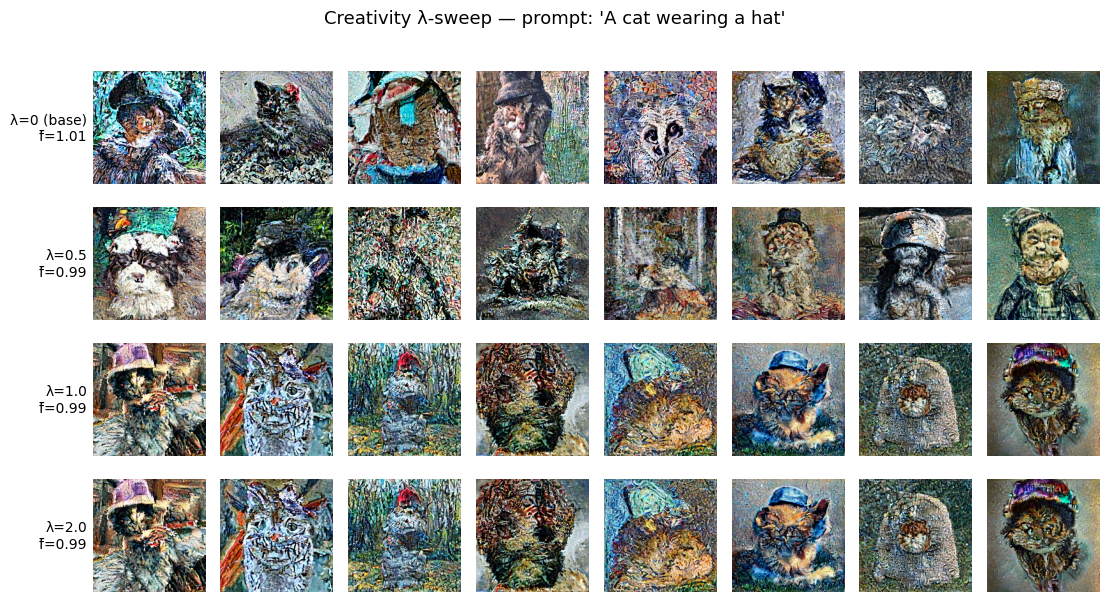

In [10]:
import matplotlib.pyplot as plt

TOPK = min(N, 8)
fig, axes = plt.subplots(
    len(ROW_LAMBDAS), TOPK, figsize=(1.4 * TOPK, 1.5 * len(ROW_LAMBDAS))
)
axes = axes.reshape(len(ROW_LAMBDAS), TOPK)  # keep 2D even if a dim is 1

for r, lam in enumerate(ROW_LAMBDAS):
    fx = scores[lam]
    order = fx.argsort(descending=True)[:TOPK]  # most-creative first
    imgs = decoded[lam][order]
    tag = "λ=0 (base)" if lam == 0.0 else f"λ={lam}"
    for c in range(TOPK):
        ax = axes[r, c]
        ax.imshow(imgs[c].permute(1, 2, 0).cpu().numpy())
        ax.set_xticks([])
        ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
    axes[r, 0].set_ylabel(
        f"{tag}\nf̄={float(fx[order].mean()):.2f}",
        rotation=0, ha="right", va="center", fontsize=10,
    )

fig.suptitle(f"Creativity λ-sweep — prompt: {PROMPT!r}", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()